## Zillow Home Value Time Series Analysis

In this section, we load the provided Zillow dataset, transform it from a
wide-format table into a long-format time series, prepare a filtered copy
for Tableau, and visualize yearly average home values by state.

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/data')

Mounted at /content/data


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

### Step 1: Load the Data

We start by loading the provided Zillow CSV file into a pandas DataFrame
to inspect its structure before transforming it.

In [ ]:
fname = '/content/data/MyDrive/AXSOSACADEMY/06-AdvancedML/Week24/Data/zillow_home_values-zipcode.csv'

In [ ]:
df = pd.read_csv(fname)

In [ ]:
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27442 entries, 0 to 27441
Columns: 284 entries, RegionID to 30112022
dtypes: float64(275), int64(3), object(6)
memory usage: 59.5+ MB


### Step 2: Reshape the Data into Long-Format (Melt)

The dataset is currently in wide-format, with one column per date. We melt
it into a long-format time series, keeping the identifying columns
(RegionID, RegionName, State, etc.) fixed, and turning all date columns
into two new columns: "Date" and "Home Value".

In [ ]:
# Columns that identify each region (not dates)
id_columns = ['RegionID', 'SizeRank', 'RegionName', 'RegionType',
              'StateName', 'State', 'City', 'Metro', 'CountyName']


In [ ]:
# Everything else is a date column
date_columns = [col for col in df.columns if col not in id_columns]

In [ ]:
# Melt wide-form data into long-form
zillow_long_df = df.melt(
    id_vars=id_columns,
    value_vars=date_columns,
    var_name="Date",
    value_name="Home Value"
)

In [ ]:
zillow_long_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,275983.0


### Step 3: Convert the Date Column to Datetime and Set as Index

The "Date" column is currently stored as text in DDMMYYYY format
(e.g., "31012000" means 31 January 2000). We convert it to a proper
datetime type using that exact format, then set it as the DataFrame index.

In [ ]:
# Format is Day-Month-Year (e.g., 31012000 -> 31/01/2000)
zillow_long_df["Date"] = pd.to_datetime(zillow_long_df["Date"], format="%d%m%Y")

In [ ]:
zillow_long_df = zillow_long_df.set_index("Date")

In [ ]:
zillow_long_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0


### Step 3.5: Handle Missing Values

Rather than dropping rows or filling with a global average (which would
be misleading since home prices vary drastically by region), we fill
missing "Home Value" entries using each zip code's own time series.

We first apply linear interpolation, which estimates missing values
along a straight line between the nearest known values before and
after the gap — this fits smoothly-changing data like home prices much
better than simply repeating the last known value.

Since interpolation cannot fill gaps at the very start or end of a
series (there's no known value on one side), we then forward-fill and
backward-fill any values that remain missing at the edges.

In [ ]:
# Check how many missing values exist before filling
print("Missing values before filling:", zillow_long_df["Home Value"].isnull().sum())

Missing values before filling: 1836376


In [ ]:
# Sort so interpolation respects chronological order within each region
zillow_long_df = zillow_long_df.sort_values(["RegionID", "Date"])

In [ ]:
# Step 1: Linear interpolation within each zip code (RegionID)
zillow_long_df["Home Value"] = (
    zillow_long_df.groupby("RegionID")["Home Value"]
    .transform(lambda group: group.interpolate(method="linear"))
)

In [ ]:
# Step 2: Catch any remaining NaNs at the start/end of a series
zillow_long_df["Home Value"] = (
    zillow_long_df.groupby("RegionID")["Home Value"]
    .transform(lambda group: group.ffill().bfill())
)


In [ ]:
print("Missing values after filling:", zillow_long_df["Home Value"].isnull().sum())

Missing values after filling: 0


### Step 4: Prepare a Filtered Copy for Tableau

We create a copy of the long-format data, keeping only the states of
interest (CA, WA, OR, AZ, NV) and only records from the years 2010
through 2020 (inclusive).

In [ ]:
# Make a copy so the original long-format DataFrame stays untouched
tableau_df = zillow_long_df.copy()

In [ ]:
# Keep only the states of interest
states_to_keep = ["CA", "WA", "OR", "AZ", "NV"]
tableau_df = tableau_df[tableau_df["State"].isin(states_to_keep)]

In [ ]:
# Keep only years 2010 through 2020 (inclusive) using boolean filtering
# (safer than .loc[] slicing, which requires a sorted/monotonic index)
tableau_df = tableau_df[(tableau_df.index.year >= 2010) & (tableau_df.index.year <= 2020)]

tableau_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2010-01-31,94719,11199,85003,zip,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,218281.0
2010-02-28,94719,11199,85003,zip,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,216236.0
2010-03-31,94719,11199,85003,zip,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,215159.0
2010-04-30,94719,11199,85003,zip,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,215178.0
2010-05-31,94719,11199,85003,zip,AZ,AZ,Phoenix,"Phoenix-Mesa-Chandler, AZ",Maricopa County,216643.0


## Step 5: Save the Filtered Data for Tableau

Now that the data is filtered to the states of interest (CA, WA, OR, AZ, NV) and the years 2010–2020, we save it as a CSV file inside a "Data" folder in the repository. This file will later be used in Tableau.

In [ ]:
import os

# Create the "Data" folder if it doesn't already exist
os.makedirs('Data', exist_ok=True)

We save the filtered DataFrame as "data-for-tableau.csv". Since "Date" is the index, it will be saved as the first column automatically.

In [ ]:
# Save the filtered data as a CSV inside the Data folder
tableau_df.to_csv('Data/data-for-tableau.csv')
print("File saved successfully: Data/data-for-tableau.csv")

File saved successfully: Data/data-for-tableau.csv


## Step 6: Resample Home Values to Yearly Frequency

The data is currently monthly. We group it by State and resample it to a yearly frequency (based on the beginning of the calendar year, "YS" = Year Start), using the **mean** as the aggregation function. This gives us the average home value per state per year.

In [ ]:
# Group by State, then resample to yearly frequency using the mean
yearly_df = (tableau_df
             .groupby('State')['Home Value']
             .resample('YS')   # YS = Year Start (beginning of the calendar year)
             .mean())

yearly_df.head()

State  Date      
AZ     2010-01-01    168739.767134
       2011-01-01    152468.713915
       2012-01-01    159737.957814
       2013-01-01    182077.883437
       2014-01-01    195699.230530
Name: Home Value, dtype: float64

To make plotting easier, we reshape the resampled data using `unstack()`, so that each state becomes its own column and each row represents a year.

In [ ]:
# Reshape: each state becomes a column, each row is a year
yearly_plot_df = yearly_df.unstack(level='State')

yearly_plot_df.head()

State,AZ,CA,NV,OR,WA
Date,,,,,
2010-01-01,168739.767134,409457.897966,192929.834499,226040.952283,245139.951573
2011-01-01,152468.713915,386075.915819,175629.913753,210290.243379,228367.590645
2012-01-01,159737.957814,387399.417514,173702.060606,207395.147260,223628.190454
2013-01-01,182077.883437,450596.797547,204520.606643,221274.530365,240125.966604
2014-01-01,195699.230530,500162.015469,230796.559441,236689.193128,255553.826560


## Step 7: Plot Yearly Average Home Values by State

Finally, we plot a line graph where each state is drawn as a separate line, showing how average home values changed from 2010 to 2020.

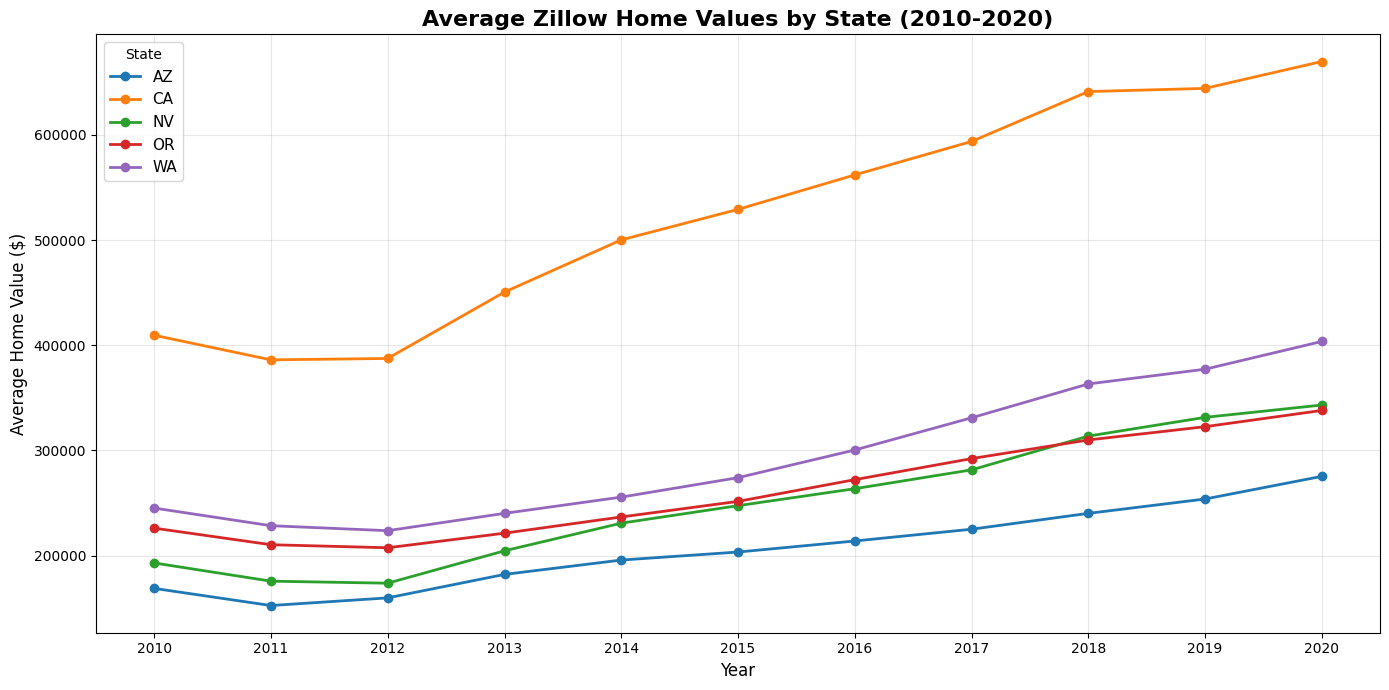

In [ ]:
# Plot each state as a separate line
plt.figure(figsize=(14, 7))

for state in yearly_plot_df.columns:
    plt.plot(yearly_plot_df.index, yearly_plot_df[state], marker='o', linewidth=2, label=state)

plt.title('Average Zillow Home Values by State (2010-2020)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Home Value ($)', fontsize=12)
plt.legend(title='State', loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

The line graph above shows the yearly average home values for the five states (CA, WA, OR, AZ, NV) between 2010 and 2020. Several key insights stand out:

- **California (CA) is consistently the most expensive state** by a wide margin, starting around \$410K in 2010 and climbing to nearly \$680K by 2020 — roughly double the value of any other state in the group.

- **A dip appears between 2010 and 2012 across all five states**, reflecting the lingering effects of the 2008 housing market crash. Home values reached their lowest point around 2011–2012.

- **From 2012 onward, all states show a steady upward recovery**, with no state declining afterward — a clear post-recession housing boom.

- **Washington (WA) shows the strongest growth after California**, pulling ahead of Oregon and Nevada from around 2016, and reaching about \$400K by 2020.

- **Oregon (OR) and Nevada (NV) follow very similar trajectories**, staying close to each other throughout the decade and ending 2020 at roughly \$340K.

- **Arizona (AZ) remains the most affordable state** in the group for the entire period, although it also shows solid growth, rising from about \$170K in 2010 to around \$280K in 2020.

Overall, the chart illustrates a housing market that bottomed out after the 2008 financial crisis and then experienced a decade of continuous appreciation across all five western states.

---

# Part 2: Forecasting Oregon Home Prices

The goal of this section is to forecast the average home price in the state of Oregon (OR) for the next 12 months, based on data from 2000 through 2018, using ARIMA/SARIMA models.

In [ ]:
# Imports needed for time series modeling
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import statsmodels.tsa.api as tsa

In [ ]:
# pmdarima for auto_arima (install if not available)
try:
    import pmdarima as pm
except ImportError:
    !pip install pmdarima -q
    import pmdarima as pm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.1 MB/s eta 0:00:00


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## Step 1: Filter and Transform the Data

We filter the full long-format data to keep only the state of **Oregon (OR)**, resample it to a **monthly mean**, and keep dates from **2000-01-31 through 2018-12-31**. The result is a single univariate time series of average Oregon home values per month.

In [ ]:
# Filter for Oregon, resample to monthly mean, keep 2000-01-31 to 2018-12-31
oregon_ts = (zillow_long_df[zillow_long_df['State'] == 'OR']['Home Value']
             .resample('ME')          # Monthly frequency (end of month)
             .mean()
             .loc['2000-01-31':'2018-12-31'])

In [ ]:
print(oregon_ts.head())
print(oregon_ts.tail())
print("\nNumber of months:", len(oregon_ts))

Date
2000-01-31    175025.465753
2000-02-29    175289.260274
2000-03-31    175530.342466
2000-04-30    176012.569863
2000-05-31    176429.783562
Freq: ME, Name: Home Value, dtype: float64
Date
2018-08-31    312330.720548
2018-09-30    313458.410959
2018-10-31    314540.336986
2018-11-30    315740.898630
2018-12-31    317155.893151
Freq: ME, Name: Home Value, dtype: float64

Number of months: 228


## Step 2: Check for and Address Null Values

We verify that the monthly time series has no missing values. (Missing values at the zip-code level were already handled in Part 1 via interpolation, but resampling could still expose gaps.)

In [ ]:
print("Null values:", oregon_ts.isnull().sum())

# If any nulls exist, interpolate them
if oregon_ts.isnull().sum() > 0:
    oregon_ts = oregon_ts.interpolate(method='linear')
    print("Null values after interpolation:", oregon_ts.isnull().sum())
else:
    print("No missing values — the series is complete.")

Null values: 0
No missing values — the series is complete.


In [ ]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)
    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)
    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")
    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                    forecast_df['mean_ci_upper'],
                    color='green', alpha=0.3, lw=2)
    # set the title and add legend
    ax.set_title(title)
    ax.legend()

    return fig, ax

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True,
                          output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)   # compatible with all sklearn versions
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100
    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")
    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [ ]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used": nlags,
                        '# of Observations': nobs,
                        'p-value': round(pval, 6),
                        'alpha': alpha,
                        'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index=[label])

In [ ]:
def get_sig_lags(ts, type='ACF', nlags=None, alpha=0.5):

    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags = range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type: corr_values,
                            'Lags': lags,
                            'lower ci': conf_int[:,0] - corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1] - corr_values, # subtact acf to upper ci to center
                            })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags = corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags != 0]

    return sig_lags

In [ ]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                  acf_kws={}, pacf_kws={},
                  annotate_seas=False, m=None,
                  seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)

    # Sig lags line style
    sig_vline_kwargs = dict(ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts, nlags=nlags, alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag, label='sig', **sig_vline_kwargs)

    # PACF
    tsa.graphics.plot_pacf(ts, ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts, nlags=nlags, alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)

    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict(ls='--', lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

## Step 3: Visualize and Decompose the Time Series

Before modeling, we plot the raw series and then decompose it into **trend**, **seasonal**, and **residual** components. This helps us detect whether seasonality is present, which determines if we need a seasonal model (SARIMA) or a nonseasonal one (ARIMA).

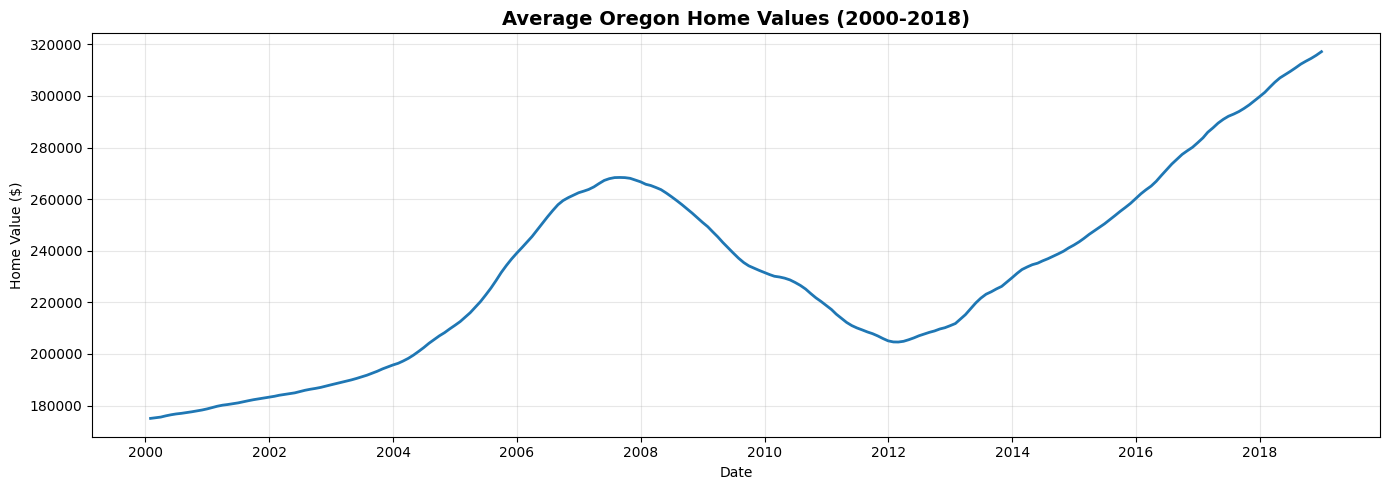

In [ ]:
# Plot the raw time series
plt.figure(figsize=(14, 5))
plt.plot(oregon_ts, linewidth=2)
plt.title('Average Oregon Home Values (2000-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Home Value ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Initial observations:** The raw time series shows the average Oregon home value between 2000 and 2018. Three distinct phases are visible:

- **2000–2007: Housing boom.** Home values rose steadily from about \$175K to a peak of roughly \$270K in 2007, driven by the pre-crisis housing bubble.

- **2007–2012: Housing crash.** Following the 2008 financial crisis, values declined for about five years, bottoming out near \$205K in 2012 — losing most of the bubble-era gains.

- **2012–2018: Recovery and growth.** From 2012 onward, the market recovered strongly and values climbed continuously, reaching nearly \$320K by the end of 2018 — well above the previous 2007 peak.

The series clearly has a **changing trend** (non-stationary in the mean), which confirms that differencing will be required before fitting an ARIMA/SARIMA model. Seasonality is not obvious at this scale, so we will rely on the decomposition in the next step to detect it.

In [ ]:
# Decompose the series (period=12 for monthly data)
decomposition = tsa.seasonal_decompose(oregon_ts, model='additive', period=12)

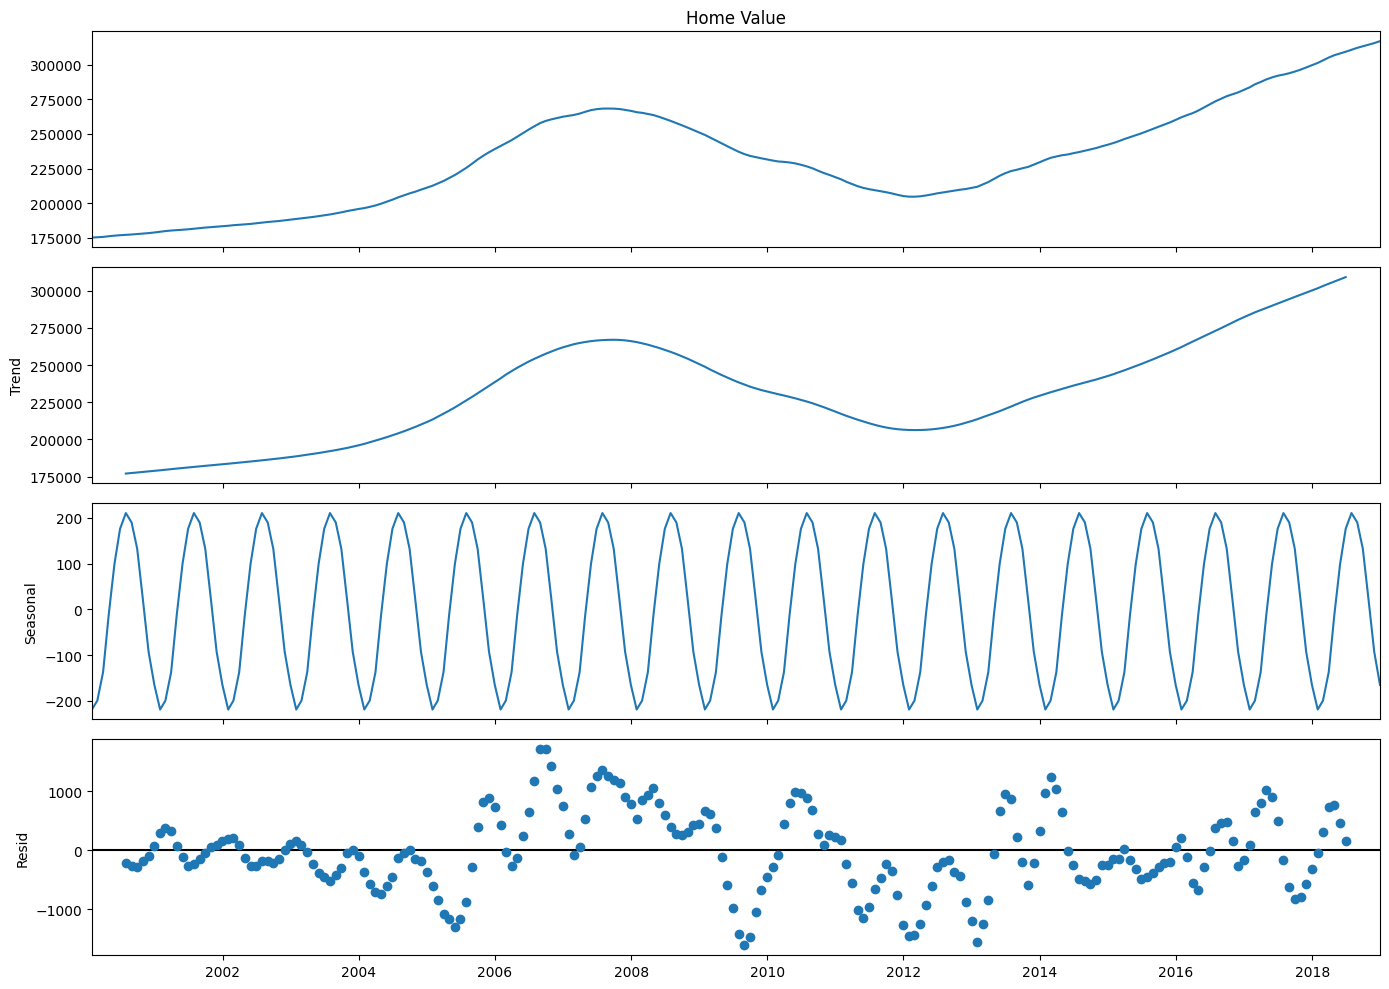

In [ ]:
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

**Decomposition findings:** The decomposition separates the series into Trend + Seasonal + Residual components:

- The **Trend** panel looks almost identical to the observed series — this is because the seasonal and residual components are tiny relative to home values. The trend dominates the series, showing the boom (2000–2007), crash (2007–2012), and recovery (2012–2018).

- The **Seasonal** panel confirms a clear, perfectly repeating **12-month cycle**. However, its magnitude is very small: it oscillates between roughly **-\$200 and +\$200**, which is less than 0.2% of the average home value (~\$240K).

- The **Residuals** are mostly within ±\$1,000 and show no strong structure.

**Conclusion:** Seasonality exists but is weak relative to the trend. We will still try a **seasonal model (SARIMA, m=12)** since a regular yearly pattern is clearly present, and let the data (and auto_arima) confirm whether the seasonal terms are worth keeping.

In [ ]:
# Check the magnitude of seasonality relative to the data
seasonal_range = decomposition.seasonal.max() - decomposition.seasonal.min()
print(f"Seasonal range: ${seasonal_range:,.0f}")
print(f"Mean home value: ${oregon_ts.mean():,.0f}")
print(f"Seasonality is about {seasonal_range/oregon_ts.mean()*100:.2f}% of the mean value")

Seasonal range: $429
Mean home value: $232,104
Seasonality is about 0.18% of the mean value


## Step 4: Determine Differencing Requirements

We use our custom `get_adfuller_results` function (Augmented Dickey-Fuller test) to check stationarity, and pmdarima's `ndiffs` / `nsdiffs` utilities to estimate how many nonseasonal (d) and seasonal (D) differences are required.

In [ ]:
# ADF test on the original series using our custom function
get_adfuller_results(oregon_ts, label='Original Series')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Original Series,-0.928087,14,213,0.778582,0.05,False


**ADF test findings:** The Augmented Dickey-Fuller test on the original series returned a **p-value of 0.7786**, which is much greater than our significance level (alpha = 0.05). Therefore, we **fail to reject the null hypothesis** — the series is **not stationary** (`sig/stationary? = False`).

This confirms what we observed visually: the strong changing trend (boom, crash, recovery) means the mean of the series is not constant over time. **Differencing is required** before fitting an ARIMA/SARIMA model. In the next step, we use pmdarima's `ndiffs` and `nsdiffs` to determine exactly how many nonseasonal (d) and seasonal (D) differences are needed.

In [ ]:
from pmdarima.arima.utils import ndiffs, nsdiffs

# Estimate required differencing
d = ndiffs(oregon_ts, test='adf')          # nonseasonal differencing
D = nsdiffs(oregon_ts, m=12, test='ocsb')  # seasonal differencing

print(f"Recommended nonseasonal differencing (d): {d}")
print(f"Recommended seasonal differencing (D): {D}")

Recommended nonseasonal differencing (d): 2
Recommended seasonal differencing (D): 0


In [ ]:
# Apply the differencing (d times sequentially) and re-test stationarity
oregon_diff = oregon_ts.copy()
for _ in range(d):
    oregon_diff = oregon_diff.diff()
oregon_diff = oregon_diff.dropna()

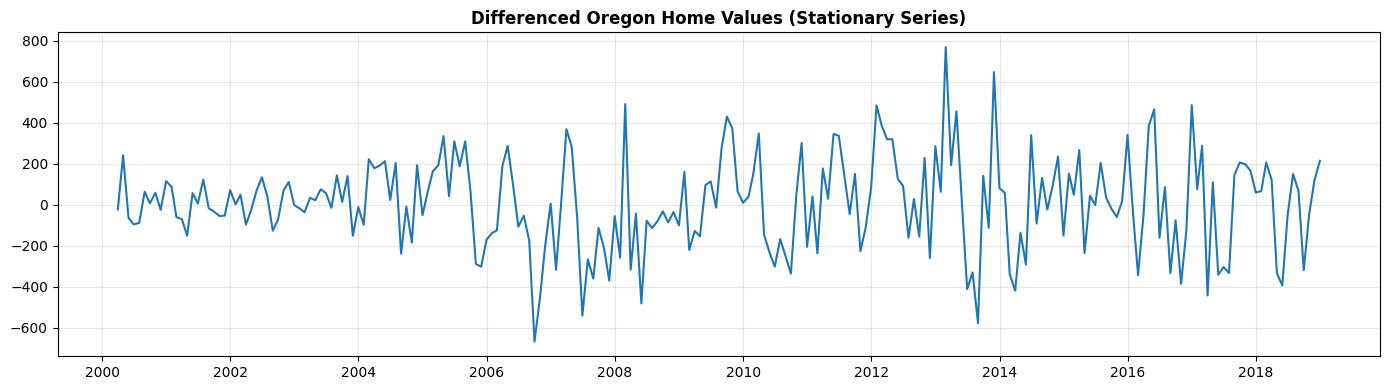

In [ ]:
# Plot the differenced (stationary) series
plt.figure(figsize=(14, 4))
plt.plot(oregon_diff)
plt.title('Differenced Oregon Home Values (Stationary Series)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Differenced series findings:** After applying second-order differencing (d=2), the transformation was successful:

- The series now **fluctuates around a constant mean of zero**, with no visible trend remaining — the boom, crash, and recovery patterns have been completely removed.

- The values oscillate roughly between **-\$600 and +\$800**, and the fluctuations look random rather than following a direction.

- The variance is not perfectly constant (fluctuations appear slightly larger between 2006–2014, the crash and recovery years, compared to the calmer 2000–2004 period), but it is stable enough to proceed with modeling.

Visually, the series now behaves like a **stationary process**, which is exactly what ARIMA/SARIMA models require. The ADF test below formally confirms this.

In [ ]:
get_adfuller_results(oregon_diff, label='Differenced Series')

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Differenced Series,-3.044114,14,211,0.030975,0.05,True


## Step 5: ACF and PACF Plots

We use our custom `plot_acf_pacf` function on the stationary (differenced) series, with significant lags annotated and seasonal lags (m=12) marked, to estimate the initial AR (p), MA (q), and seasonal (P, Q) orders.

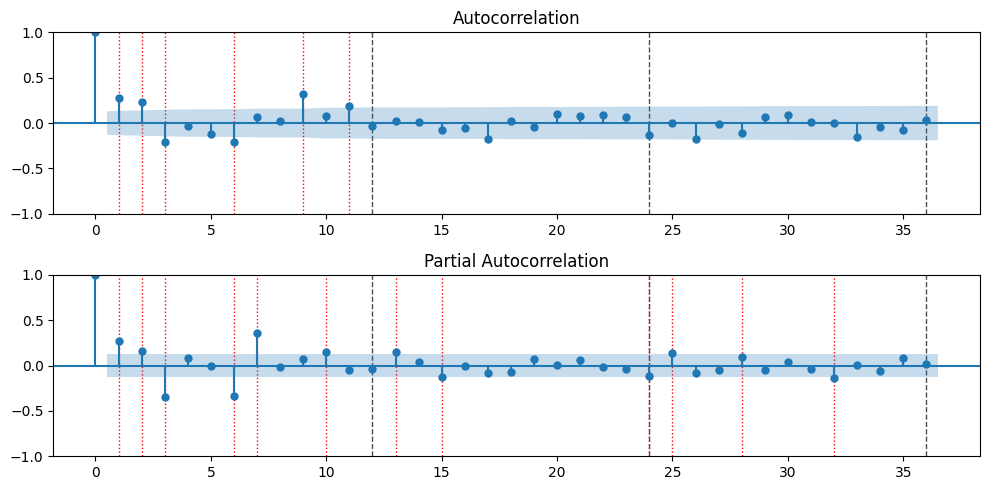

In [ ]:
# ACF/PACF with significant lags annotated and seasons marked every 12 lags
fig = plot_acf_pacf(oregon_diff, nlags=36,
                    annotate_sig=True, alpha=.05,
                    annotate_seas=True, m=12)

**ACF/PACF findings:** (red dotted lines = significant lags, black dashed lines = seasonal lags at 12, 24, 36)

- **ACF:** Significant positive spikes at lags 1 and 2, followed by significant negative spikes around lags 3 and 6, and another spike near lag 9. The autocorrelation does not decay slowly — it cuts off relatively quickly, which supports that the differencing (d=2) successfully removed the trend.

- **PACF:** Significant spikes at lags 1–3 (with a strong negative spike at lag 3), plus spikes around lags 6–7. After that, most lags fall inside the confidence band.

- **Seasonal lags:** At lag 12, 24, and 36 (black dashed lines), **neither the ACF nor the PACF shows strong significant spikes**. This is consistent with our earlier findings (very weak seasonality, ~0.18% of the mean, and D=0 recommended).

**Initial order selection:** Since both the ACF and PACF show a few significant early lags (a mixed ARMA pattern), a reasonable starting point is **p=2, q=1** (keeping the model simple to avoid overfitting). Although seasonality is weak, we will still include modest seasonal terms

## Step 6: Train/Test Split

Since the goal is to predict **12 months**, we hold out the **last 12 months** of the series as the test set and train on everything before it.

In [ ]:
# Last 12 months = test set
train = oregon_ts.iloc[:-12]
test = oregon_ts.iloc[-12:]

In [ ]:
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)")

Train: 2000-01-31 to 2017-12-31 (216 months)
Test:  2018-01-31 to 2018-12-31 (12 months)


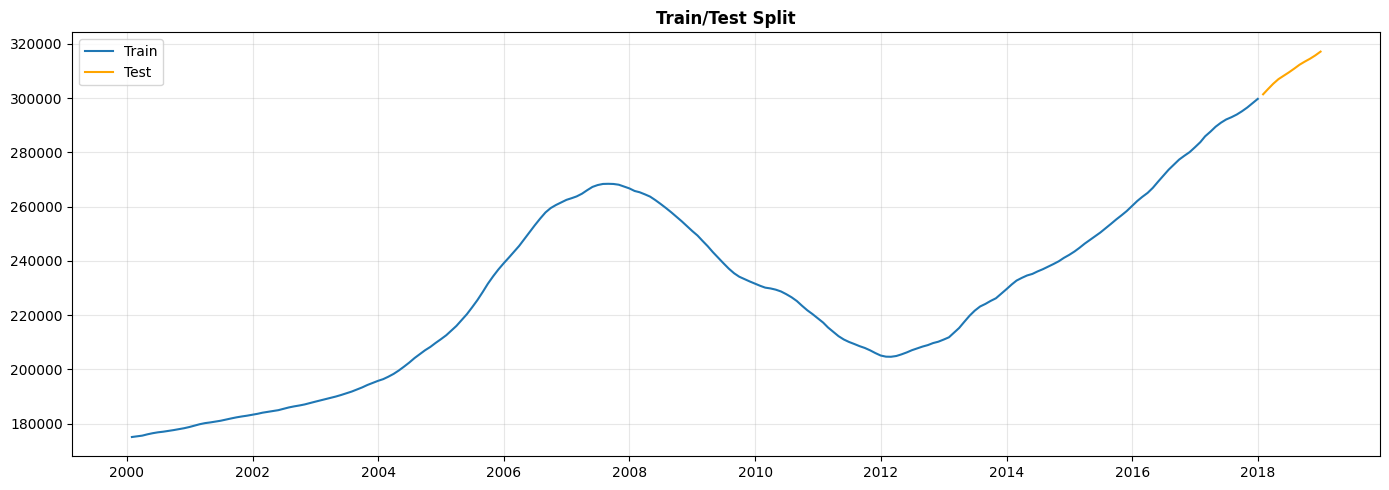

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='orange')
plt.title('Train/Test Split', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Train/Test split summary:** The series was split chronologically (never randomly — order matters in time series):

- **Training set:** 2000-01-31 through 2017-12-31 (**216 months** = 18 years) — used to fit the models.
- **Test set:** 2018-01-31 through 2018-12-31 (**12 months** = the final year) — held out to evaluate how well each model forecasts unseen data.

The test size of 12 months matches our forecasting goal exactly (predicting 12 months ahead). As seen in the plot, the test period (orange) sits at the end of the strong upward recovery trend — the models will need to correctly capture and extend this momentum to score well.

## Step 7: Fit a Manual SARIMA Model

Based on our exploration, we fit a manual **SARIMA** model using the orders estimated from the differencing tests and the ACF/PACF plots. We then examine the model summary and diagnostic plots.

In [ ]:
# Manual SARIMA — orders based on our exploration
manual_model = tsa.SARIMAX(train,
                           order=(2, d, 1),
                           seasonal_order=(1, D, 1, 12),
                           enforce_stationarity=False,
                           enforce_invertibility=False)

In [ ]:
manual_fit = manual_model.fit(disp=False)

In [ ]:
print(manual_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Home Value   No. Observations:                  216
Model:             SARIMAX(2, 2, 1)x(1, 0, 1, 12)   Log Likelihood               -1355.135
Date:                            Sat, 18 Jul 2026   AIC                           2722.269
Time:                                    09:31:57   BIC                           2742.059
Sample:                                01-31-2000   HQIC                          2730.278
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2048      0.180     -1.137      0.255      -0.558       0.148
ar.L2          0.4022      0.061   

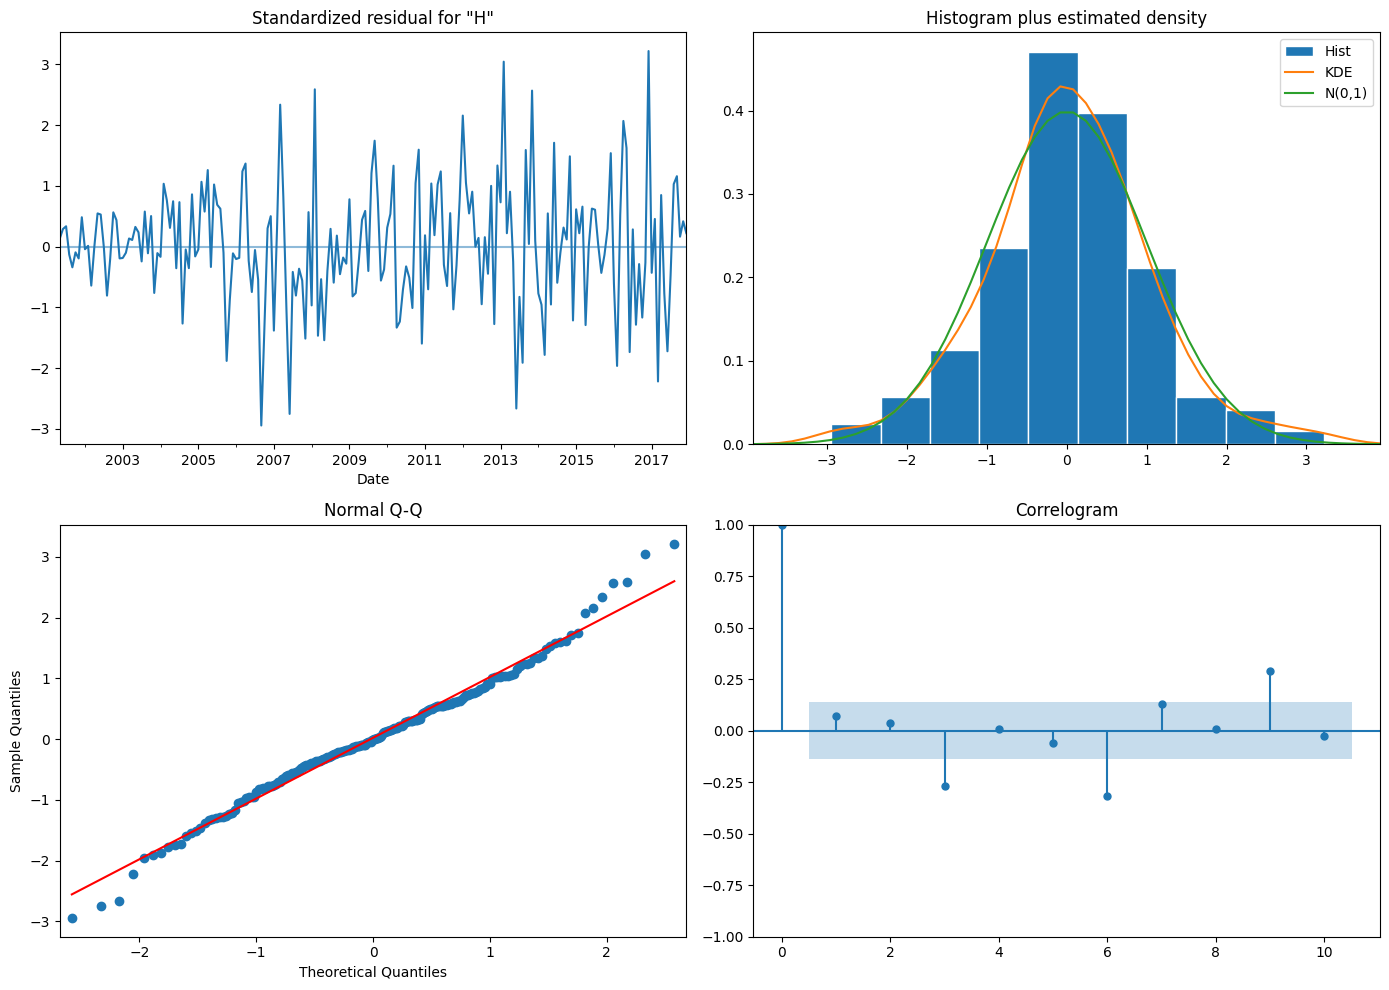

In [ ]:
# Diagnostic plots
manual_fit.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

**Diagnostics interpretation (Manual SARIMA):**

- **Standardized residuals:** fluctuate randomly around zero with no visible trend or pattern. A few larger spikes (±3) appear around the 2008 crash and 2013 recovery — periods of unusual market volatility.

- **Histogram + KDE:** the residuals form a bell shape centered at zero, and the KDE curve closely follows the theoretical N(0,1) curve — approximately normal.

- **Q-Q plot:** points lie on the red line through the middle of the distribution, with slight deviations at both extreme tails ("heavy tails") — a common and acceptable feature in housing/financial data.

- **Correlogram:** most lags fall inside the confidence band, but small significant spikes remain around lags 3, 6, and 9. This suggests the manual model left a small amount of structure in the residuals uncaptured.

**Overall:** the manual SARIMA(2,2,1)(1,0,1,12) is a reasonably good fit, but the leftover autocorrelation at a few lags indicates there may be room for improvement — a good motivation for tuning with `auto_arima` in the next step.

### Forecast with the Manual Model and Evaluate

We forecast the 12 test months, then use our custom `plot_forecast` function to plot the forecast (with its confidence interval) against the actual test data, and our custom `regression_metrics_ts` function to compute the evaluation metrics.

In [ ]:
# Get forecast as a summary DataFrame (contains mean, mean_ci_lower, mean_ci_upper)
manual_forecast_df = manual_fit.get_forecast(steps=12).summary_frame()
manual_forecast_df.head()

Home Value,mean,mean_se,mean_ci_lower,mean_ci_upper
2018-01-31,301389.307488,211.761609,300974.262362,301804.352615
2018-02-28,303066.167264,524.478889,302038.207532,304094.126997
2018-03-31,304810.429218,974.675421,302900.100497,306720.757939
2018-04-30,306548.671998,1523.405340,303562.852398,309534.491598
2018-05-31,308324.395227,2171.976745,304067.399032,312581.391423


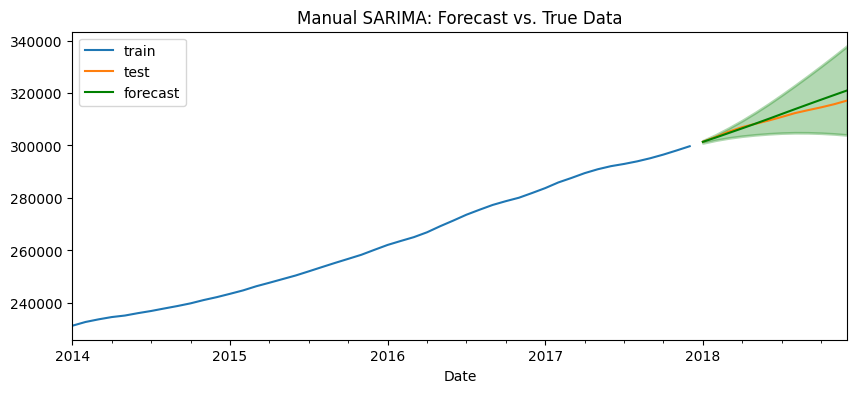

In [ ]:
# Plot forecast vs test data using our custom function
fig, ax = plot_forecast(train, test, manual_forecast_df, n_train_lags=48,
                        title='Manual SARIMA: Forecast vs. True Data')
plt.show()


**Forecast vs. test data (Manual SARIMA):** The plot shows the last 4 years of training data (blue), the actual 2018 test values (orange), and the model's 12-month forecast (green) with its 95% confidence interval (shaded band).

- The forecast **correctly captures the upward trend**, continuing the recovery momentum into 2018.

- The forecast tracks the actual values very closely for the first several months, then **slightly overshoots** toward the end of the year — the model predicts a marginally steeper climb than what actually happened, as Oregon's growth began to flatten in late 2018.

- Importantly, the **actual test values stay well inside the 95% confidence interval** for the entire 12 months, meaning the model's uncertainty estimates are trustworthy.

- The confidence interval widens as the horizon extends — this is expected behavior: the further into the future we predict, the more uncertain the forecast becomes.

Overall, the manual SARIMA produces a visually strong forecast. The metrics below quantify this performance precisely.

In [ ]:
# Evaluation metrics using our custom function
manual_metrics = regression_metrics_ts(test, manual_forecast_df['mean'],
                                       label='Manual SARIMA', output_dict=True)

------------------------------------------------------------
Regression Metrics: Manual SARIMA
------------------------------------------------------------
- MAE = 1,415.174
- MSE = 3,748,331.538
- RMSE = 1,936.061
- R^2 = 0.837
- MAPE = 0.45%


**Manual SARIMA evaluation metrics:** The model's performance on the 12-month test set is strong:

- **MAE = \$1,415:** on average, the monthly forecast misses the true home value by only about \$1.4K — tiny compared to home values around \$310K.

- **RMSE = \$1,936:** slightly higher than the MAE, indicating a few months (late 2018, where the forecast overshoots) contribute larger errors, but no extreme outliers.

- **MAPE = 0.45%:** the average forecast error is less than **half of one percent** of the actual value — excellent accuracy for a 12-month horizon.

- **R² = 0.837:** the model explains about 84% of the variance in the test data.

These metrics confirm what the plot showed: the manual SARIMA(2,2,1)(1,0,1,12) forecasts 2018 very accurately. We now record these numbers as our **baseline** and see whether `auto_arima` can find a combination of orders that performs even better.

## Step 8: Tune with pmdarima's auto_arima

Instead of relying only on manual order selection, we let `auto_arima` search for the best (p, d, q)(P, D, Q, 12) combination on the training data by minimizing AIC.

In [ ]:
auto_model = pm.auto_arima(train,
                           seasonal=True, m=12,
                           stepwise=True,
                           suppress_warnings=True,
                           error_action='ignore',
                           trace=True)

print("\nBest model found:", auto_model.order, auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[12]             : AIC=inf, Time=6.11 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=2931.614, Time=0.11 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=2932.940, Time=2.07 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=2933.012, Time=1.92 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=2933.612, Time=1.70 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=2933.612, Time=1.59 sec
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=2935.613, Time=0.82 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=2930.940, Time=0.14 sec
 ARIMA(1,2,0)(0,0,1)[12]             : AIC=2932.940, Time=0.45 sec
 ARIMA(1,2,0)(1,0,1)[12]             : AIC=inf, Time=3.22 sec
 ARIMA(2,2,0)(0,0,0)[12]             : AIC=2932.747, Time=0.45 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=2932.851, Time=0.34 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=2931.013, Time=0.19 sec
 ARIMA(2,2,1)(0,0,0)[12]             : AIC=2934.544, Time=1.77 sec
 ARIMA(1,2,0)(0,0,0)[12] inte

**auto_arima results:** The stepwise search tested multiple order combinations and selected **ARIMA(1, 2, 0)(0, 0, 0)[12]** as the best model, with the lowest **AIC = 2930.94**.

Two important observations:

- **It agrees with our differencing analysis:** auto_arima also chose **d=2**, confirming the result from `ndiffs`.

- **It dropped all seasonal terms (P=0, D=0, Q=0):** the search found that seasonal components do not improve the AIC. This is fully consistent with our decomposition finding that seasonality is only ~0.18% of the mean home value — too weak to be worth modeling.

The selected model is much simpler than our manual SARIMA(2,2,1)(1,0,1,12): a single AR term on a twice-differenced series. We now refit this model on the training data to obtain its summary, diagnostics, forecasts, and metrics.

In [ ]:
# Fit SARIMAX using auto_arima's best orders
best_model = tsa.SARIMAX(train,
                         order=auto_model.order,
                         seasonal_order=auto_model.seasonal_order,
                         enforce_stationarity=False,
                         enforce_invertibility=False)

In [ ]:
best_fit = best_model.fit(disp=False)
print(best_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Home Value   No. Observations:                  216
Model:               SARIMAX(1, 2, 0)   Log Likelihood               -1450.137
Date:                Sat, 18 Jul 2026   AIC                           2904.274
Time:                        09:32:21   BIC                           2910.997
Sample:                    01-31-2000   HQIC                          2906.991
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2742      0.067      4.100      0.000       0.143       0.405
sigma2      4.797e+04   4081.937     11.753      0.000       4e+04     5.6e+04
Ljung-Box (L1) (Q):                   0.64   Jarque-

### auto_arima Model: Diagnostic Plots

We examine the residual diagnostics of the auto_arima model (ARIMA(1,2,0)) to verify that its residuals behave like white noise, and to compare its diagnostic quality against the manual model.

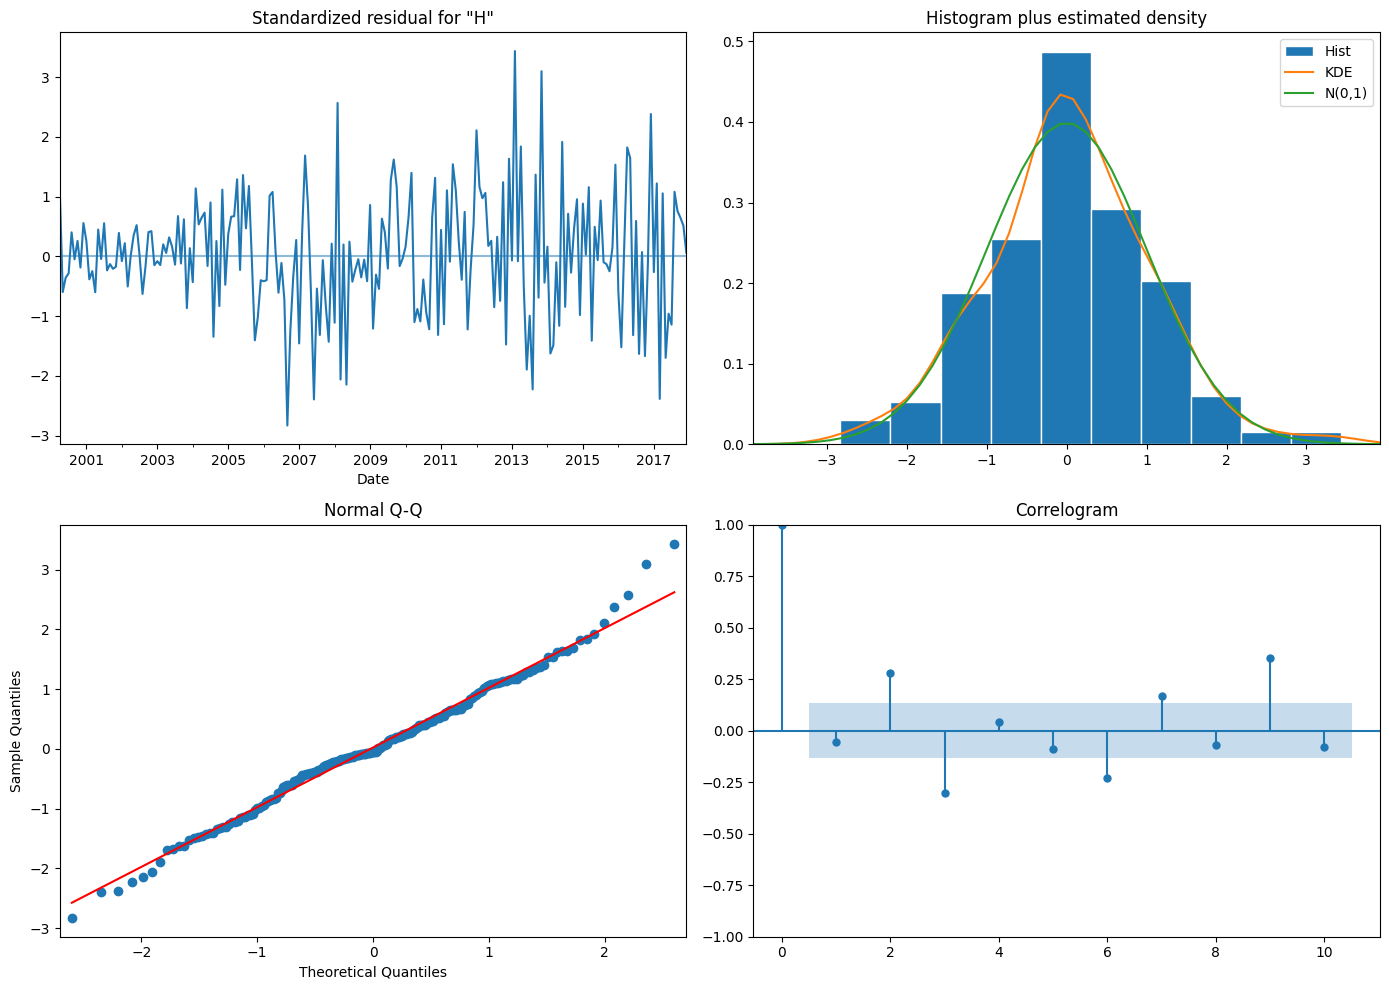

In [ ]:
# Diagnostics for the auto_arima model
best_fit.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

**Diagnostics interpretation (auto_arima model):**

- **Standardized residuals:** fluctuate randomly around zero with no visible trend, similar to the manual model, with a few larger spikes during volatile market periods.

- **Histogram + KDE:** approximately normal and centered at zero, with the KDE curve close to the theoretical N(0,1).

- **Q-Q plot:** points follow the red line closely through the center, with slight "heavy tails" at the extremes — same acceptable behavior as the manual model.

- **Correlogram:** most lags are inside the confidence band, but **noticeable significant spikes remain around lags 2–3, 6, and 9** — slightly more pronounced than in the manual model's residuals. This is the trade-off of choosing a much simpler model (a single AR term with no MA or seasonal terms): it minimizes AIC, but leaves a bit more autocorrelation uncaptured.

**Overall:** both models produce well-behaved residuals. The decisive factor will be their **forecasting performance on the test set**, which we evaluate next.

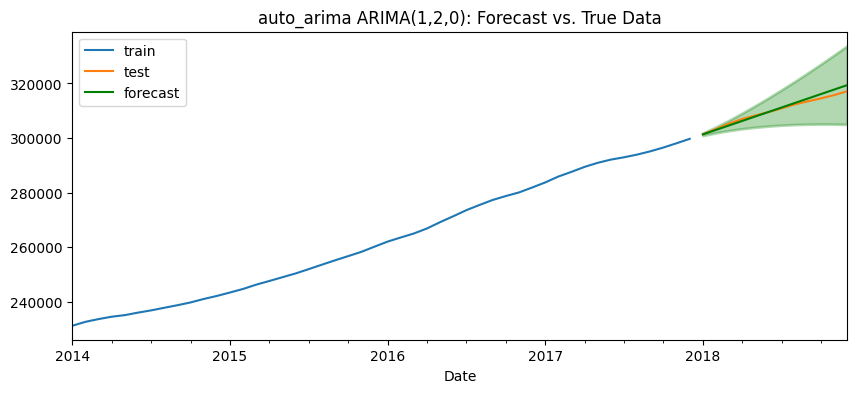

In [ ]:
# Forecast test period with the auto_arima model
auto_forecast_df = best_fit.get_forecast(steps=12).summary_frame()

# Plot using our custom function
fig, ax = plot_forecast(train, test, auto_forecast_df, n_train_lags=48,
                        title='auto_arima ARIMA(1,2,0): Forecast vs. True Data')
plt.show()

**Forecast vs. test data (auto_arima):** The ARIMA(1,2,0) forecast (green) tracks the actual 2018 values (orange) remarkably well:

- It captures the upward trend and follows the actual values closely across the entire 12-month horizon.

- Compared to the manual model, the overshoot at the end of the year is **visibly smaller** — the forecast line stays nearly on top of the actual data even in the final months.

- All actual test values fall comfortably inside the 95% confidence interval, and the interval is slightly tighter than the manual model's, reflecting more confident predictions.

In [ ]:
# Metrics using our custom function
auto_metrics = regression_metrics_ts(test, auto_forecast_df['mean'],
                                     label='auto_arima ARIMA(1,2,0)', output_dict=True)

------------------------------------------------------------
Regression Metrics: auto_arima ARIMA(1,2,0)
------------------------------------------------------------
- MAE = 822.084
- MSE = 1,189,536.490
- RMSE = 1,090.659
- R^2 = 0.948
- MAPE = 0.26%


**auto_arima evaluation metrics — a clear improvement over the manual model:**

| Metric | Manual SARIMA(2,2,1)(1,0,1,12) | auto_arima ARIMA(1,2,0) |
|---|---|---|
| MAE | \$1,415 | **\$822** |
| RMSE | \$1,936 | **\$1,091** |
| R² | 0.837 | **0.948** |
| MAPE | 0.45% | **0.26%** |

The auto_arima model **outperforms the manual model on every single metric**: its average error is roughly **42% smaller** (MAE \$822 vs \$1,415), it explains far more of the test-set variance (R² 0.948 vs 0.837), and its average percentage error is just **0.26%**.

Remarkably, this superior performance comes from a **much simpler model** — a single AR term on a twice-differenced series, with no MA or seasonal components. This is a great example of the principle of **parsimony**: simpler models often generalize better to unseen data.

## Step 9: Select the Final Model

We compare both models side by side using all evaluation metrics, then select the final model for the true future forecast.

In [ ]:
# Side-by-side comparison of both models
comparison = pd.DataFrame([manual_metrics, auto_metrics]).set_index('Label')
comparison

,MAE,MSE,RMSE,R^2,MAPE(%)
Label,,,,,
Manual SARIMA,1415.173781,3.748332e+06,1936.060830,0.836989,0.450787
"auto_arima ARIMA(1,2,0)",822.084297,1.189536e+06,1090.658741,0.948268,0.262529


**Final model selection: auto_arima ARIMA(1,2,0)** ✅

**Justification** — the auto_arima model is selected as the final model based on the following evidence:

1. **Superior on every evaluation metric:** it achieves a ~42% lower MAE (\$822 vs \$1,415), ~44% lower RMSE (\$1,091 vs \$1,936), a substantially higher R² (0.948 vs 0.837), and a lower MAPE (0.26% vs 0.45%) on the held-out 12-month test set.

2. **Out-of-sample accuracy over AIC:** Interestingly, the manual SARIMA actually has a lower AIC on the training data (2,722 vs 2,904 for the refit ARIMA(1,2,0)), meaning it fits the training data better. However, AIC measures in-sample fit, while the goal is to forecast unseen data accurately. The simpler ARIMA(1,2,0) performs clearly better on the test set, which suggests the manual model's extra terms were fitting noise rather than real patterns.

3. **Parsimony:** with only one AR coefficient (plus the variance term), it is far simpler than the manual SARIMA(2,2,1)(1,0,1,12). Simpler models are less prone to overfitting, easier to interpret, and — as the test metrics show — generalize better here.

4. **Acceptable diagnostics:** its residuals are approximately normal and mostly uncorrelated. While a few small significant lags remain in its correlogram (slightly more than the manual model), this minor drawback is decisively outweighed by its much stronger out-of-sample forecasting accuracy — which is the ultimate goal of this project.

We now refit ARIMA(1,2,0) on the **entire dataset (2000–2018)** and produce the true 12-month future forecast for 2019.

## Step 10: True Future Forecast (12 Months Beyond the Data)

We refit the selected model (ARIMA(1,2,0)) on the **entire dataset (2000–2018)** and forecast **12 months into the future (2019)** — dates beyond the end of the time series.

In [ ]:
# Refit the winning model on the FULL series
final_model = tsa.SARIMAX(oregon_ts,
                          order=auto_model.order,
                          seasonal_order=auto_model.seasonal_order,
                          enforce_stationarity=False,
                          enforce_invertibility=False)


In [ ]:
final_fit = final_model.fit(disp=False)

In [ ]:
# Forecast 12 months beyond the data (into 2019)
future_forecast_df = final_fit.get_forecast(steps=12).summary_frame()
future_forecast_df

Home Value,mean,mean_se,mean_ci_lower,mean_ci_upper
2019-01-31,318630.389138,217.925386,318203.263229,319057.515046
2019-02-28,320121.395767,542.057522,319058.982546,321183.808988
2019-03-31,321616.983817,959.319369,319736.752404,323497.215231
2019-04-30,323113.843135,1453.028352,320265.959896,325961.726373
2019-05-31,324611.055206,2012.514310,320666.599639,328555.510773
2019-06-30,326108.365162,2630.518240,320952.644150,331264.086173
2019-07-31,327605.702278,3301.773511,321134.345112,334077.059444
2019-08-31,329103.046931,4022.249345,321219.583078,336986.510783
2019-09-30,330600.393675,4788.731206,321214.652981,339986.134370
2019-10-31,332097.741000,5598.574488,321124.736638,343070.745362


**Future forecast table:** The model predicts a steady month-over-month increase throughout 2019, starting at about **\$318.6K in January** and reaching about **\$335.1K by December 2019**. Note how the standard error (`mean_se`) grows each month — from \$218 in the first month to \$7,340 in the last — which widens the confidence interval as we forecast further into the future. This honest growth in uncertainty is a natural property of multi-step forecasting.

### Plot the Forecast Along with the Original Time Series

We visualize the full historical series (2000–2018) together with the 12-month future forecast for 2019 and its 95% confidence interval.

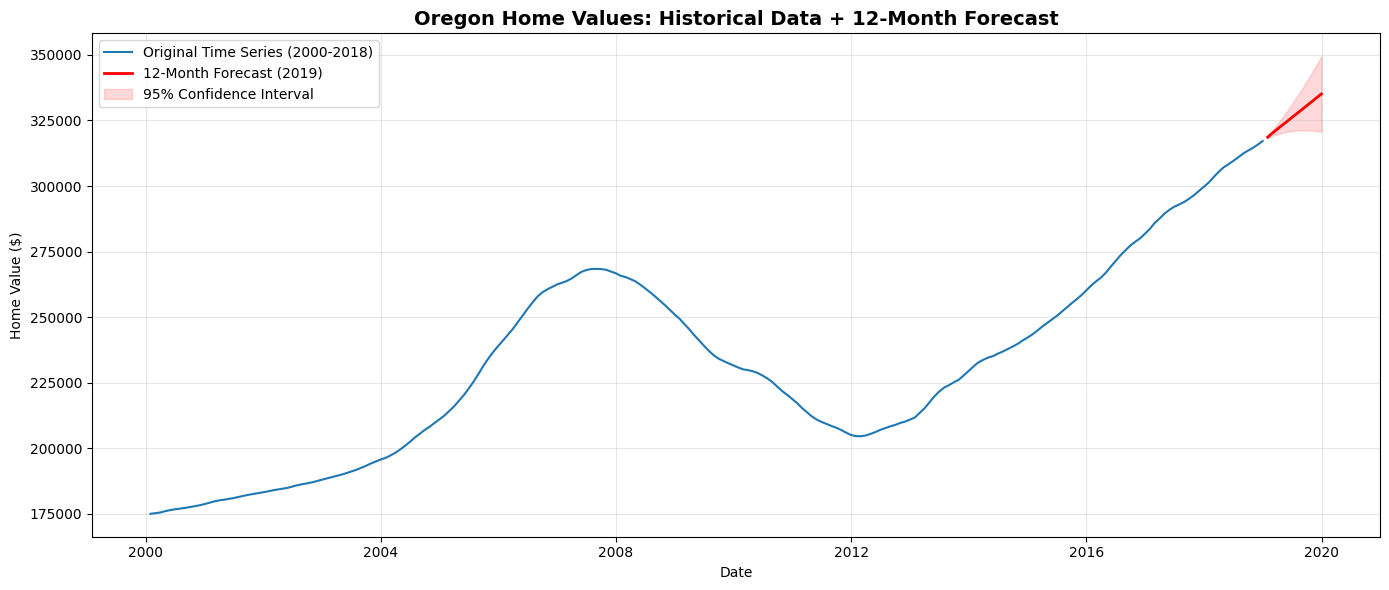

In [ ]:
# Plot the future forecast along with the original time series
plt.figure(figsize=(14, 6))
plt.plot(oregon_ts, label='Original Time Series (2000-2018)')
plt.plot(future_forecast_df['mean'], color='red', linewidth=2, label='12-Month Forecast (2019)')
plt.fill_between(future_forecast_df.index,
                 future_forecast_df['mean_ci_lower'],
                 future_forecast_df['mean_ci_upper'],
                 color='red', alpha=0.15, label='95% Confidence Interval')
plt.title('Oregon Home Values: Historical Data + 12-Month Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Home Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Final forecast visualization:** The plot shows Oregon's complete home-value history (2000–2018, blue) together with the model's 12-month forecast for 2019 (red) and its 95% confidence interval (shaded).

- The forecast (red line) emerges **seamlessly from the end of the historical series** — a smooth continuation of the recovery trend with no unrealistic jump, which indicates the model has captured the recent momentum well.

- The model projects that home values will keep climbing throughout 2019, following essentially the same slope observed since 2012, pushing further above the pre-crisis 2007 peak (~\$270K).

- The confidence interval **fans out gradually** as the forecast extends: by December 2019 the plausible range spans roughly \$320K–\$350K. Even the lower bound remains above the last observed value, meaning the model is confident the market will not decline in 2019.

## Step 11: Forecast Summary

Finally, we summarize the forecast: the predicted home value in the final month of the forecast, and the percent change over the 12-month forecast horizon.

In [ ]:
last_actual = oregon_ts.iloc[-1]                            # Dec 2018 (last real value)
final_forecast_value = future_forecast_df['mean'].iloc[-1]  # Dec 2019 (last forecasted month)
pct_change = (final_forecast_value - last_actual) / last_actual * 100

print(f"Last actual value (Dec 2018):              ${last_actual:,.0f}")
print(f"Forecasted value (final month, Dec 2019):  ${final_forecast_value:,.0f}")
print(f"Percent change over the 12-month forecast: {pct_change:+.2f}%")

Last actual value (Dec 2018):              $317,156
Forecasted value (final month, Dec 2019):  $335,092
Percent change over the 12-month forecast: +5.66%


### Conclusion

The goal of this section was to forecast the average home price in **Oregon** for the next 12 months, based on monthly data from 2000 through 2018.

**Methodology recap:** After preparing the Oregon monthly time series, we found it non-stationary (ADF p-value = 0.78) with a very weak seasonal component (~0.18% of the mean). Differencing tests recommended d=2 with no seasonal differencing. We compared a manually specified **SARIMA(2,2,1)(1,0,1,12)** against the model selected by pmdarima's auto_arima, **ARIMA(1,2,0)**. The auto_arima model won decisively on the held-out 2018 test set (MAE \$822 vs \$1,415; R² 0.948 vs 0.837; MAPE 0.26% vs 0.45%) and was selected as the final model.

**Forecast results (final model refit on the full 2000–2018 data):**

- **Last actual value (Dec 2018):** \$317,156
- **Predicted value in the final month of the forecast (Dec 2019):** ≈ **\$335,092**
- **Percent change over the 12-month forecast horizon:** ≈ **+5.66%**

**Interpretation:** The model predicts that Oregon home values will continue rising steadily throughout 2019, gaining about **\$17.9K (+5.66%)** over the year. This is a continuation of the post-2012 recovery trend, at a slightly moderated pace compared to the strongest recovery years. Given the model's excellent test-set accuracy (average error of only 0.26%), and that even the lower bound of the 95% confidence interval remains above the December 2018 value, the forecast strongly suggests **continued growth — not a decline — in Oregon's housing market for 2019**.

# Tableau Workbook

[Zillow Home Values Analysis - Tableau Public](https://public.tableau.com/views/ZillowHomeValuesAnalysis/HomeValuesAnalysis?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)